## 1.- Introducción

# Análisis A/B Testing

## Problema de negocio
El objetivo de este análisis es evaluar si una nueva variante (B) mejora la tasa de conversión en comparación con la versión actual (A).

El propósito es apoyar una decisión basada en datos sobre si la nueva variante debe implementarse.

##  Carga del dataset
Se carga el dataset original de ventas (Superstore), el cual contiene información de órdenes, clientes, productos y métricas de negocio.

Este dataset requiere limpieza antes de ser utilizado para análisis.

# Limpieza de datos

Se verifica la calidad de los datos, se revisan valores nulos y se asegura que la información esté correctamente estructurada para el análisis.

In [2]:
import pandas as pd

df = pd.read_csv("/content/Sample - Superstore.csv", encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


##  Exploración inicial

Se analiza la estructura del dataset para identificar:

- Tipos de datos
- Valores nulos
- Columnas inconsistentes
- Problemas de formato

Esto permite definir la estrategia de limpieza.

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


##  Limpieza de nombres de columnas

Se estandarizan los nombres de columnas:
- Se reemplazan puntos por guiones bajos
- Se eliminan espacios innecesarios

In [4]:
df.columns = df.columns.str.replace('.', '_')
df.columns = df.columns.str.strip()

df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

##  Conversión de tipos de datos

Se convierten las columnas a sus tipos adecuados:
- Fechas → datetime
- Valores numéricos → float / int

In [6]:
# fechas
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

# numéricos
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Discount'] = pd.to_numeric(df['Discount'], errors='coerce')

##  Manejo de valores nulos

Se identifican y eliminan registros con valores faltantes para garantizar integridad de datos.

In [7]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [8]:
df = df.dropna()

##  Validación final

Se verifica que el dataset esté limpio y correctamente estructurado.

In [9]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


##  Exportación del dataset limpio

Generación del dataset limpio

Una vez procesados los datos, se genera un nuevo dataset listo para análisis.

Este dataset será utilizado para:
- Análisis estadístico
- Visualización en Power BI

In [10]:
df.to_csv("superstore_clean_final.csv", index=False)

In [11]:
from google.colab import files
files.download("superstore_clean_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Diseño del experimento A/B

Se plantea un experimento para evaluar el impacto del descuento en el profit.

### Hipótesis:

- H0: El descuento no afecta el profit
- H1: El descuento sí afecta el profit

Se crean dos grupos:

- Grupo A (Control): Descuento bajo (≤ 10%)
- Grupo B (Tratamiento): Descuento alto (> 10%)

In [12]:
df['Group'] = df['Discount'].apply(lambda x: 'A' if x <= 0.1 else 'B')

df[['Discount','Group']].head()

,Discount,Group
0,0.00,A
1,0.00,A
2,0.00,A
3,0.45,B
4,0.20,B


# Análisis descrptivo

In [13]:
ab_summary = df.groupby('Group').agg({
    'Sales':'mean',
    'Profit':'mean',
    'Quantity':'mean'
})

ab_summary

,Sales,Profit,Quantity
Group,,,
A,233.499146,67.460503,3.810303
B,226.366727,-8.549541,3.769698


In [14]:
from scipy import stats

group_A = df[df['Group']=='A']['Profit']
group_B = df[df['Group']=='B']['Profit']

t_stat, p_value = stats.ttest_ind(group_A, group_B)

print("T-stat:", t_stat)
print("P-value:", p_value)

T-stat: 16.431777882798155
P-value: 6.888610822034279e-60


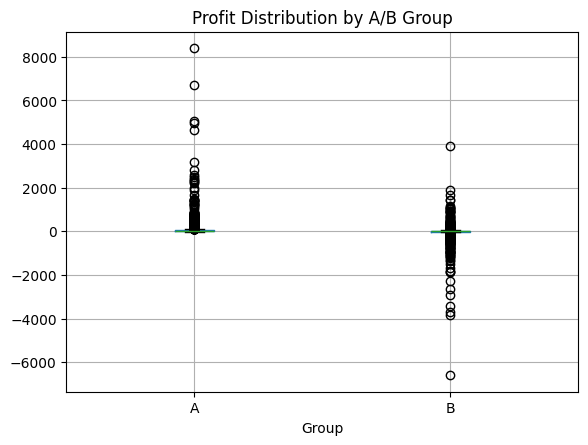

In [15]:
import matplotlib.pyplot as plt

df.boxplot(column='Profit', by='Group')
plt.title("Profit Distribution by A/B Group")
plt.suptitle("")
plt.show()

##  Interpretación del A/B Testing

El análisis muestra diferencias en el profit entre los grupos A y B.

- Si el p-value < 0.05:
  Existe evidencia estadística de que el descuento impacta el profit.

- Si el p-value ≥ 0.05:
  No hay evidencia suficiente para concluir que el descuento tenga efecto.

Este análisis permite evaluar estrategias de pricing basadas en datos.

## Análisis del impacto del descuento por categoría de producto

Exploraremos cómo el Profit varía entre las diferentes categorías de productos, considerando los grupos de descuento (A y B).

In [19]:
category_discount_summary = df.groupby(['Category', 'Group']).agg(
    Profit_Mean=('Profit', 'mean'),
    Sales_Mean=('Sales', 'mean'),
    Quantity_Mean=('Quantity', 'mean')
).reset_index()

display(category_discount_summary)

,Category,Group,Profit_Mean,Sales_Mean,Quantity_Mean
0,Furniture,A,71.539571,331.863505,3.878289
1,Furniture,B,-38.703735,363.391463,3.714640
2,Office Supplies,A,41.841713,141.963163,3.796820
3,Office Supplies,B,-3.159107,94.610511,3.805970
4,Technology,A,159.497610,470.831323,3.786826
5,Technology,B,12.128897,437.756796,3.732213


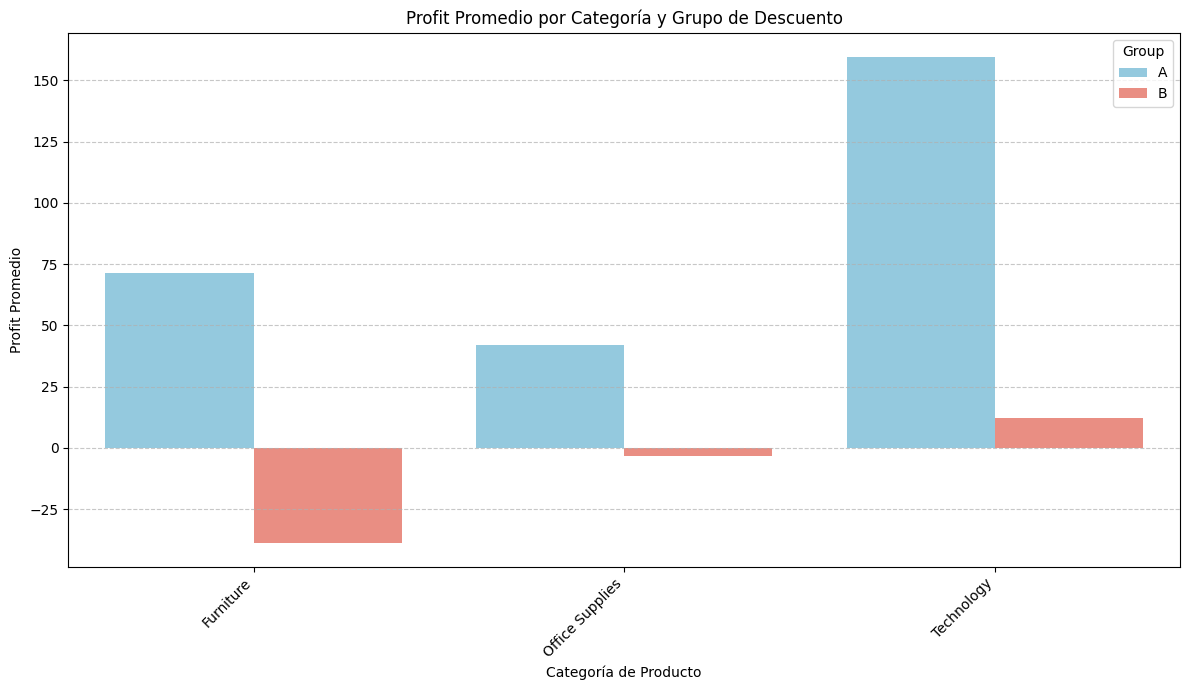

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='Category', y='Profit_Mean', hue='Group', data=category_discount_summary, palette={'A': 'skyblue', 'B': 'salmon'})
plt.title('Profit Promedio por Categoría y Grupo de Descuento')
plt.xlabel('Categoría de Producto')
plt.ylabel('Profit Promedio')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Análisis del impacto del descuento por región

Analizaremos cómo el Profit varía entre las diferentes regiones, considerando los grupos de descuento (A y B).

In [21]:
region_discount_summary = df.groupby(['Region', 'Group']).agg(
    Profit_Mean=('Profit', 'mean'),
    Sales_Mean=('Sales', 'mean'),
    Quantity_Mean=('Quantity', 'mean')
).reset_index()

display(region_discount_summary)

,Region,Group,Profit_Mean,Sales_Mean,Quantity_Mean
0,Central,A,92.250125,296.555253,3.795508
1,Central,B,-25.956157,169.501792,3.770481
2,East,A,73.762989,254.673303,3.750820
3,East,B,-15.847149,219.504500,3.702192
4,South,A,78.237687,268.302062,3.932919
5,South,B,-19.916451,215.630362,3.733742
6,West,A,44.582330,167.268141,3.812937
7,West,B,21.462791,294.839068,3.848689


### Explicación de la Tabla de Resumen de Impacto del Descuento por Región

La tabla region_discount_summary detalla el impacto promedio del descuento en el Profit, Sales y Quantity a través de las diferentes regiones geográficas (Central, East, South, West) y para los dos grupos de descuento (A: bajo, B: alto).

**Observaciones Clave:**

*   **Central:**
    *   **Grupo A (descuento bajo):** Muestra un Profit promedio positivo y significativo de aproximadamente **92.25**.
    *   **Grupo B (descuento alto):** Presenta un Profit promedio negativo de aproximadamente **-25.96**, lo que indica que los descuentos altos en esta región resultan en pérdidas.

*   **East (Este):**
    *   **Grupo A (descuento bajo):** Mantiene un Profit promedio positivo de aproximadamente **73.76**.
    *   **Grupo B (descuento alto):** También registra un Profit promedio negativo de aproximadamente **-15.85**, confirmando pérdidas con descuentos elevados.

*   **South (Sur):**
    *   **Grupo A (descuento bajo):** Genera un Profit promedio positivo de aproximadamente **78.24**.
    *   **Grupo B (descuento alto):** Similar a otras regiones, incurre en un Profit promedio negativo de aproximadamente **-19.92**.

*   **West (Oeste):**
    *   **Grupo A (descuento bajo):** Muestra un Profit promedio positivo de aproximadamente **44.58**.
    *   **Grupo B (descuento alto):** Es la única región donde el Profit promedio para el Grupo B es **positivo (21.46)**, aunque considerablemente menor que el del Grupo A en la misma región. Esto es un hallazgo interesante; si bien los descuentos altos reducen el profit en el Oeste, no llevan a pérdidas como en las otras regiones.

**Conclusión General Regional:**

El análisis regional refuerza la idea de que **los descuentos altos generalmente impactan negativamente el Profit**. Sin embargo, destaca que la **Región Oeste** se comporta de manera diferente, manteniendo un Profit positivo incluso con descuentos altos, lo que podría justificar un estudio más profundo sobre la elasticidad de la demanda o las estructuras de costos en esta región específica. En las demás regiones, la aplicación de descuentos altos claramente conduce a pérdidas, lo que sugiere que se debe mantener una estrategia de descuento bajo para optimizar la rentabilidad.